# **Import libraries**

In [82]:
# !pip install crucio

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score
from crucio import SMOTEENN, SMOTE, ICOTE, TKRKNN, SLS, MWMOTE
%matplotlib inline

In [3]:
sns.set_palette('viridis')

# **Load Dataset**

In [4]:
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "abcsds/pokemon",
  'Pokemon.csv',
)

Using Colab cache for faster access to the 'pokemon' dataset.


# **Analyse Dataset**

There is no price column. I'll take correlation with Legendary.

In [5]:
df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [6]:
df.drop(['#', 'Name'], axis=1, inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Type 1      800 non-null    object
 1   Type 2      414 non-null    object
 2   Total       800 non-null    int64 
 3   HP          800 non-null    int64 
 4   Attack      800 non-null    int64 
 5   Defense     800 non-null    int64 
 6   Sp. Atk     800 non-null    int64 
 7   Sp. Def     800 non-null    int64 
 8   Speed       800 non-null    int64 
 9   Generation  800 non-null    int64 
 10  Legendary   800 non-null    bool  
dtypes: bool(1), int64(8), object(2)
memory usage: 63.4+ KB


In [8]:
df['Legendary'] = df['Legendary'].astype(int)

In [9]:
df.nunique()

,0
Type 1,18
Type 2,18
Total,200
HP,94
Attack,111
Defense,103
Sp. Atk,105
Sp. Def,92
Speed,108
Generation,6


In [10]:
dum_cols = ['Type 1', 'Type 2']

df = pd.get_dummies(df, columns=dum_cols)

In [11]:
df_corr = df.copy()

[]

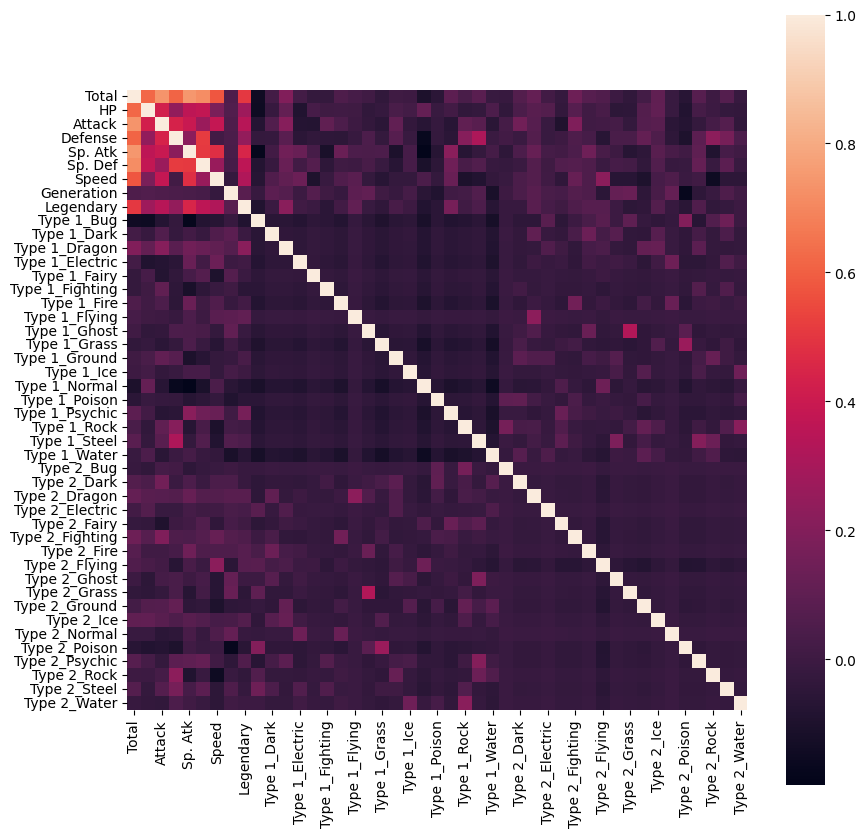

In [12]:
plt.figure(figsize=(10,10))

sns.heatmap(df_corr.corr(), square=True)

plt.plot()

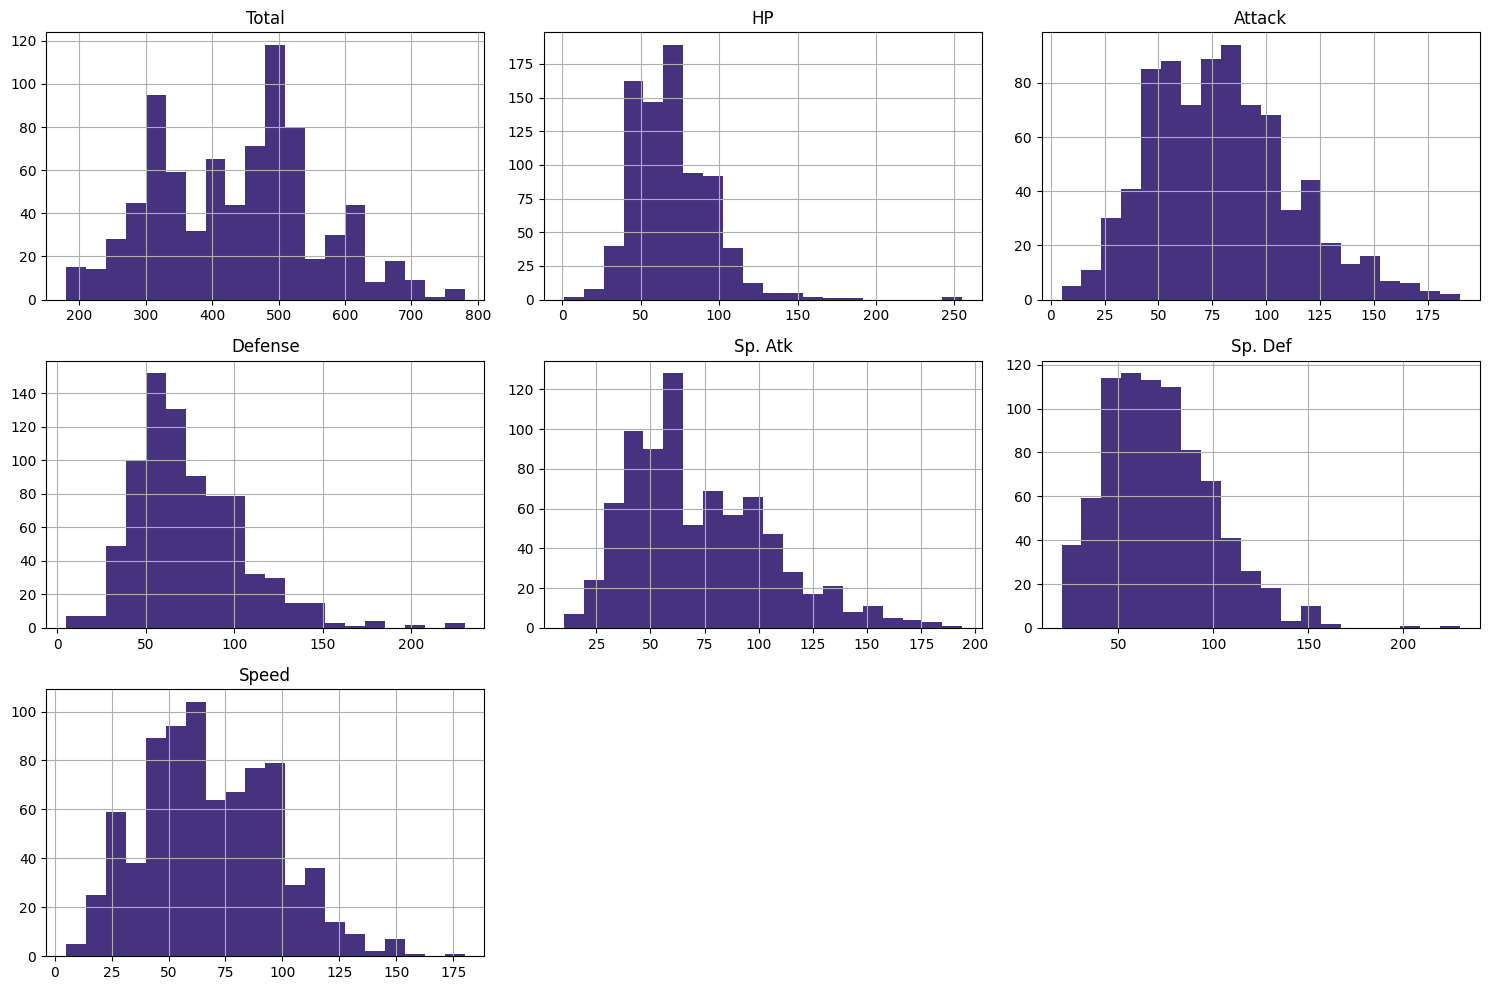

In [13]:
df.drop(['Legendary', 'Generation'], axis=1).hist(bins=20, figsize=(15, 10))

plt.tight_layout()
plt.show()

The majority of columns have skewed data(which is obvious as there cannot be many legendary pokemons)

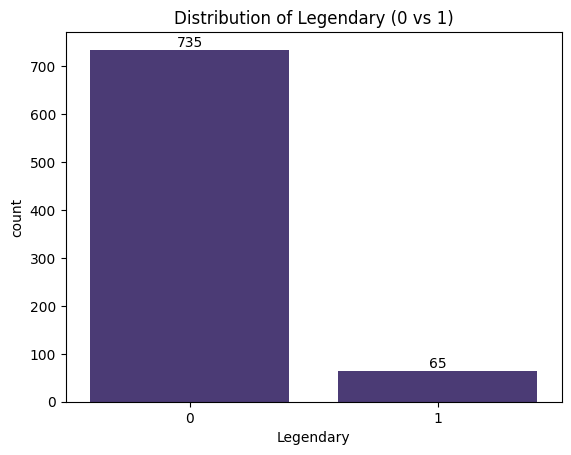

In [14]:
ax = sns.countplot(x=df['Legendary'])

ax.bar_label(ax.containers[0])

plt.title('Distribution of Legendary (0 vs 1)')
plt.show()

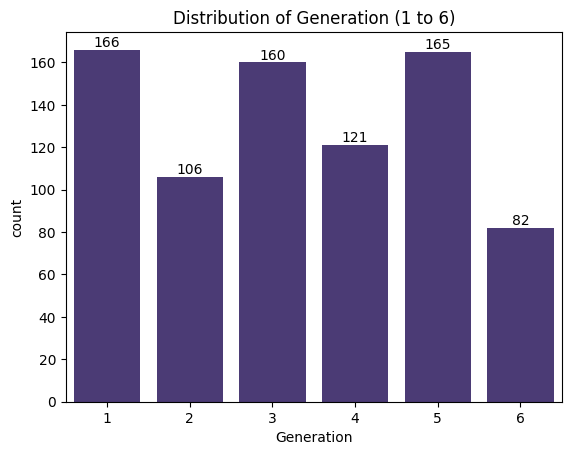

In [15]:
ax = sns.countplot(x=df['Generation'])

ax.bar_label(ax.containers[0])

plt.title('Distribution of Generation (1 to 6)')
plt.show()

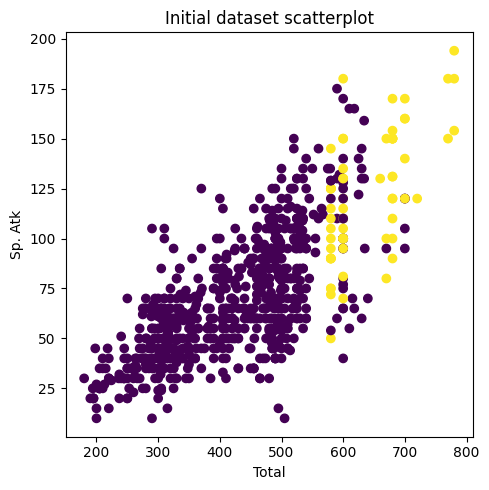

In [16]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))

colors = df['Legendary'].astype(int)

scatter = ax.scatter(df['Total'], df['Sp. Atk'], c=colors, cmap='viridis')

ax.set_title('Initial dataset scatterplot')
ax.set_xlabel('Total')
ax.set_ylabel('Sp. Atk')

plt.tight_layout()
plt.show()

## **Scale Dataset**

## **Split Dataset**

In [17]:
X = df.drop('Legendary', axis=1)
y = df['Legendary']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)

In [18]:
std_scaler = StandardScaler()
cols_to_scale = ['Sp. Atk', 'Sp. Def', 'Total', 'Speed', 'Defense', 'Attack', 'HP']

X_train[cols_to_scale] = std_scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = std_scaler.transform(X_test[cols_to_scale])

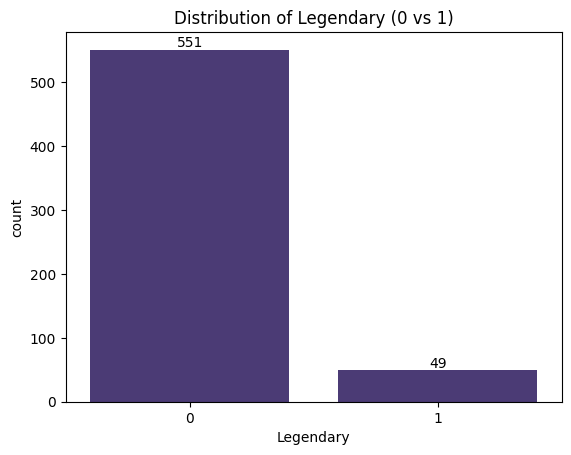

In [19]:
ax = sns.countplot(x=y_train)

ax.bar_label(ax.containers[0])

plt.title('Distribution of Legendary (0 vs 1)')
plt.show()

# **Class Balancing**

In [20]:
scores = []

## **Initial data**

In [21]:
lr = LogisticRegression(random_state=42)

lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print('Score for initial data: ', f1_score(y_pred, y_test))

Score for initial data:  0.42857142857142855


In [22]:
scores.append(['LR', 'initial', f1_score(y_pred, y_test)])

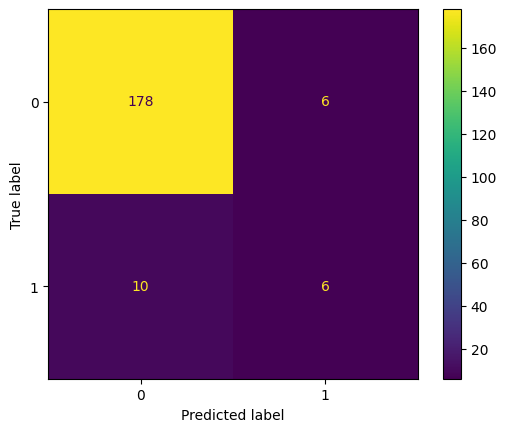

In [23]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.show()

As we see, at initial data LogisticRegression works quite badly, as it mismatches more than half of positives.

In [24]:
knc = KNeighborsClassifier()

knc.fit(X_train, y_train)
y_pred = knc.predict(X_test)
print('Score for initial data: ', f1_score(y_pred, y_test))

Score for initial data:  0.5625


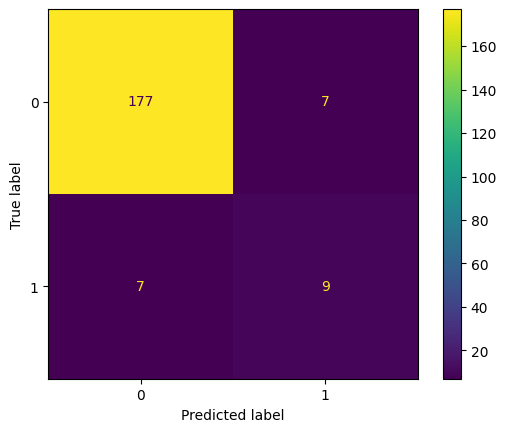

In [25]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.show()

As for KNC, it does better job. but still mismatches are quite often.

In [26]:
scores.append(['KNC', 'initial', f1_score(y_pred, y_test)])

## **SMOTE**

In [27]:
smote = SMOTE()

df_balanced = smote.balance(pd.concat([X_train, y_train], axis=1).copy(), target='Legendary')

X_balanced = df_balanced.drop('Legendary', axis=1)
y_balanced = df_balanced['Legendary']

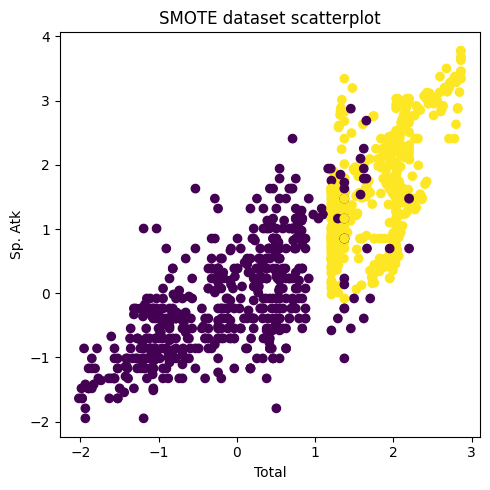

In [28]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))

colors = df_balanced['Legendary'].astype(int)

scatter = ax.scatter(df_balanced['Total'], df_balanced['Sp. Atk'], c=colors, cmap='viridis')

ax.set_title('SMOTE dataset scatterplot')
ax.set_xlabel('Total')
ax.set_ylabel('Sp. Atk')

plt.tight_layout()
plt.show()

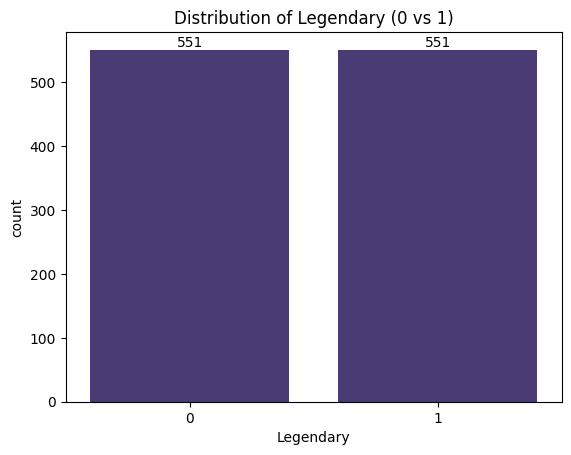

In [29]:
ax = sns.countplot(x=y_balanced)

ax.bar_label(ax.containers[0])

plt.title('Distribution of Legendary (0 vs 1)')
plt.show()

As expected, the number of Legendary has become the same as the number of non-Legendary.

In [30]:
lr = LogisticRegression(random_state=42)

lr.fit(X_balanced, y_balanced)
y_pred = lr.predict(X_test)
print('Score for SMOTE data: ', f1_score(y_pred, y_test))

Score for SMOTE data:  0.5909090909090909


In [31]:
scores.append(['LR', 'SMOTE', f1_score(y_pred, y_test)])

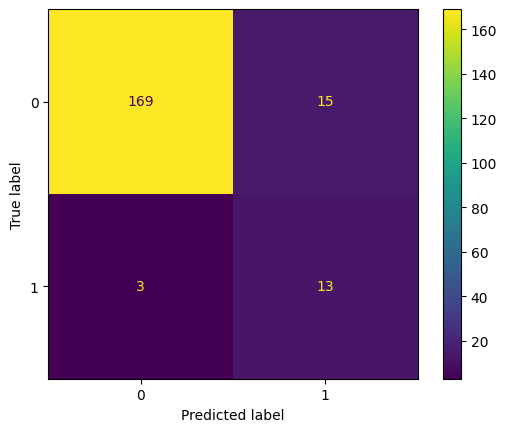

In [32]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.show()

Now, it finds more Legendary Pokemons. However, there is a downside - now it missclassifies a bunch of simple pokemons.

This is may be due to the fact some of the non-legendary samples got caught among the SMOTE-generated samples.

In [33]:
knc = KNeighborsClassifier()

knc.fit(X_balanced, y_balanced)
y_pred = knc.predict(X_test)
print('Score for SMOTE data: ', f1_score(y_pred, y_test))

Score for SMOTE data:  0.5833333333333334


In [34]:
scores.append(['KNC', 'SMOTE', f1_score(y_pred, y_test)])

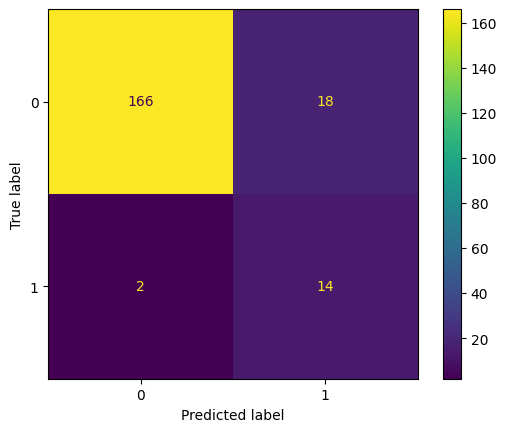

In [35]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.show()

Better than logistic regression, mayve because of the point which are near the frontier, which may be misclassified by LR.

## **SMOTEENN**

In [36]:
smotenn = SMOTEENN()

df_balanced = smotenn.balance(pd.concat([X_train, y_train], axis=1).copy().reset_index(drop=True), 'Legendary')

X_balanced = df_balanced.drop('Legendary', axis=1)
y_balanced = df_balanced['Legendary']

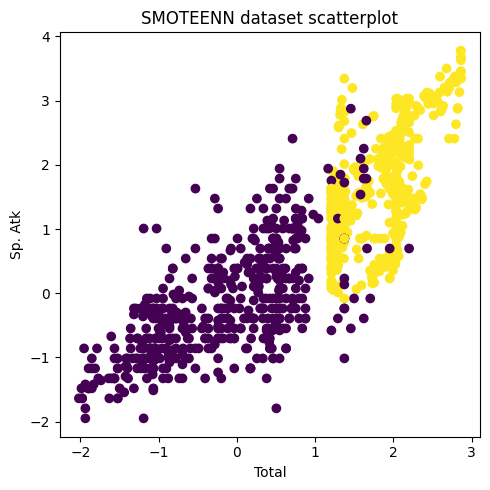

In [37]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))

colors = df_balanced['Legendary'].astype(int)

scatter = ax.scatter(df_balanced['Total'], df_balanced['Sp. Atk'], c=colors, cmap='viridis')

ax.set_title('SMOTEENN dataset scatterplot')
ax.set_xlabel('Total')
ax.set_ylabel('Sp. Atk')

plt.tight_layout()
plt.show()

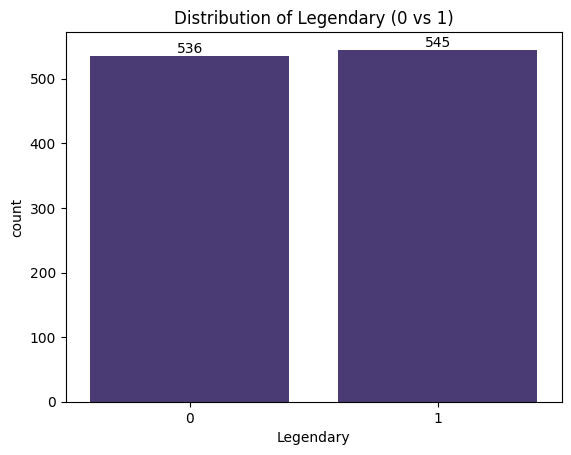

In [38]:
ax = sns.countplot(x=y_balanced)

ax.bar_label(ax.containers[0])

plt.title('Distribution of Legendary (0 vs 1)')
plt.show()

A little bit different - now, there are a bit more Legendary pokemons.

In [39]:
lr = LogisticRegression(random_state=42)

lr.fit(X_balanced, y_balanced)
y_pred = lr.predict(X_test)
print('Score for SMOTEENN data: ', f1_score(y_pred, y_test))

Score for SMOTEENN data:  0.6086956521739131


In [40]:
scores.append(['LR', 'SMOTEENN', f1_score(y_pred, y_test)])

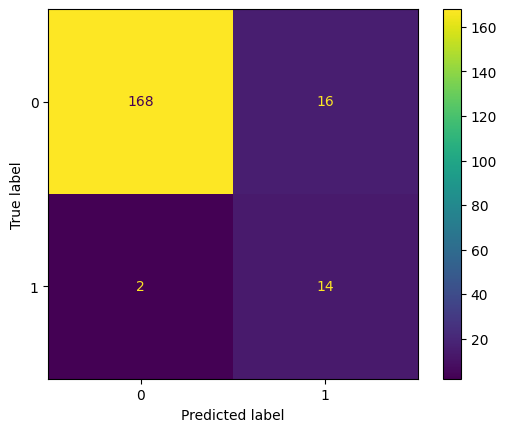

In [41]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.show()

The best results achieved - almost all legendary pokemons found, but false positives persist.

In [42]:
knc = KNeighborsClassifier()

knc.fit(X_balanced, y_balanced)
y_pred = knc.predict(X_test)
print('Score for SMOTEENN data: ', f1_score(y_pred, y_test))

Score for SMOTEENN data:  0.5714285714285714


In [43]:
scores.append(['KNC', 'SMOTEENN', f1_score(y_pred, y_test)])

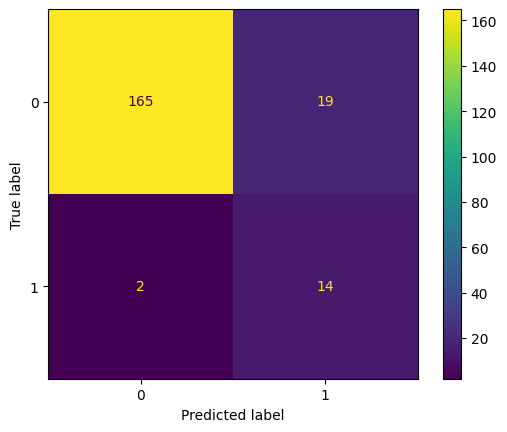

In [44]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.show()

Results are a bit worse...

## **ICOTE**

In [45]:
icote = ICOTE()

df_balanced = icote.balance(pd.concat([X_train, y_train], axis=1).copy().reset_index(drop=True), 'Legendary')

X_balanced = df_balanced.drop('Legendary', axis=1)
y_balanced = df_balanced['Legendary']

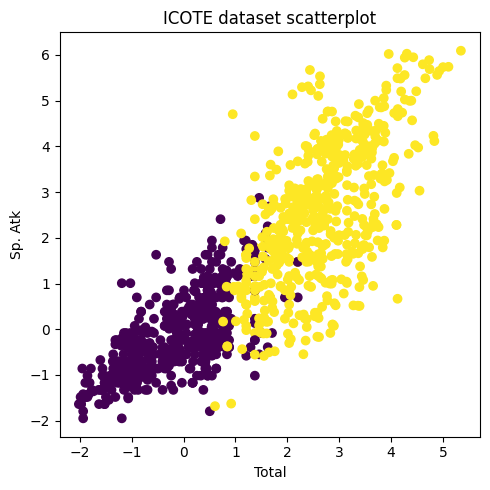

In [46]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))

colors = df_balanced['Legendary'].astype(int)

scatter = ax.scatter(df_balanced['Total'], df_balanced['Sp. Atk'], c=colors, cmap='viridis')

ax.set_title('ICOTE dataset scatterplot')
ax.set_xlabel('Total')
ax.set_ylabel('Sp. Atk')

plt.tight_layout()
plt.show()

It really fights hard the non-legendary pokemons...

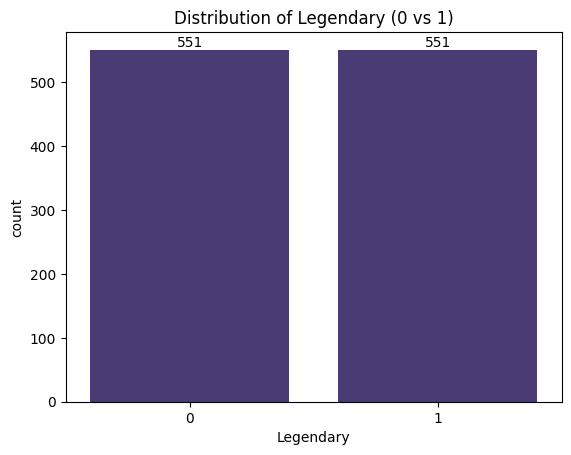

In [47]:
ax = sns.countplot(x=y_balanced)

ax.bar_label(ax.containers[0])

plt.title('Distribution of Legendary (0 vs 1)')
plt.show()

But this shows us that actually even though they looks like there are a lot of them, actually they are just a little bit more sparse.

In [48]:
lr = LogisticRegression(random_state=42)

lr.fit(X_balanced, y_balanced)
y_pred = lr.predict(X_test)
print('Score for ICOTE data: ', f1_score(y_pred, y_test))

Score for ICOTE data:  0.6060606060606061


In [49]:
scores.append(['LR', 'ICOTE', f1_score(y_pred, y_test)])

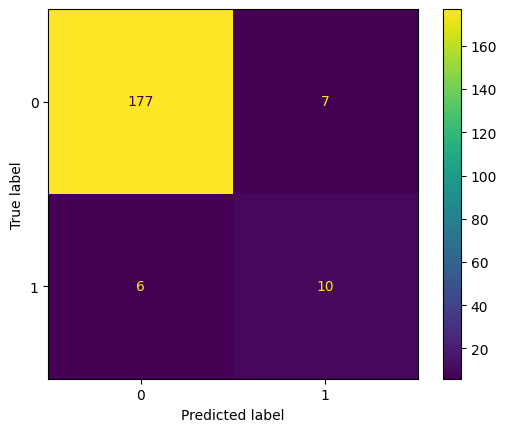

In [50]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.show()

Because they are sparse and lie outside of the normal range, they act differently on linear correlation and achieve slightly better results.

In [51]:
knc = KNeighborsClassifier()

knc.fit(X_balanced, y_balanced)
y_pred = knc.predict(X_test)
print('Score for ICOTE data: ', f1_score(y_pred, y_test))

Score for ICOTE data:  0.6470588235294118


In [52]:
scores.append(['KNC', 'ICOTE', f1_score(y_pred, y_test)])

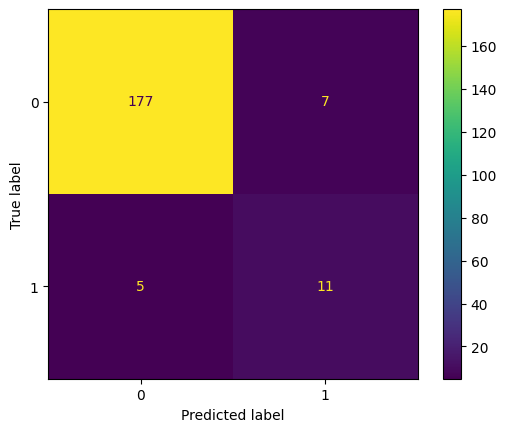

In [53]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.show()

It is bad in finding true positives, but still better than initial(it even is somewhat comparable for true negatives)

## **TKRKNN**

In [54]:
tkrknn = TKRKNN()

df_balanced = tkrknn.balance(pd.concat([X_train, y_train], axis=1).copy().reset_index(drop=True), 'Legendary')

X_balanced = df_balanced.drop('Legendary', axis=1)
y_balanced = df_balanced['Legendary']

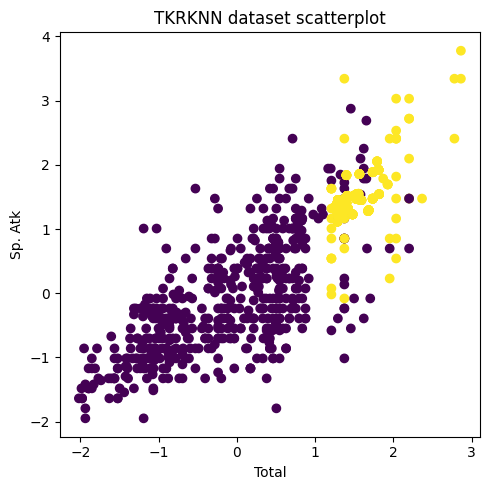

In [55]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))

colors = df_balanced['Legendary'].astype(int)

scatter = ax.scatter(df_balanced['Total'], df_balanced['Sp. Atk'], c=colors, cmap='viridis')

ax.set_title('TKRKNN dataset scatterplot')
ax.set_xlabel('Total')
ax.set_ylabel('Sp. Atk')

plt.tight_layout()
plt.show()

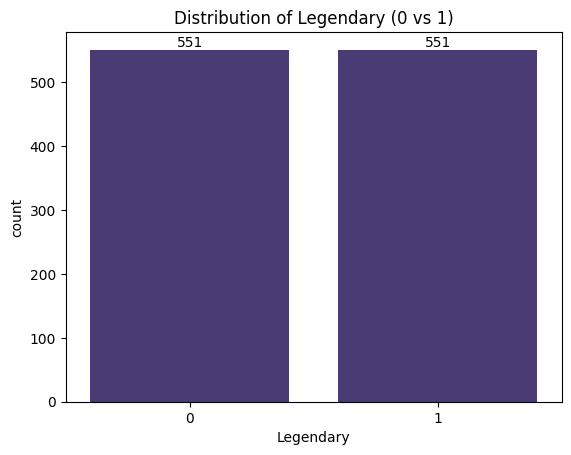

In [56]:
ax = sns.countplot(x=y_balanced)

ax.bar_label(ax.containers[0])

plt.title('Distribution of Legendary (0 vs 1)')
plt.show()

The scatterplot shows that the samples are really close one to another...

In [57]:
lr = LogisticRegression(random_state=42)

lr.fit(X_balanced, y_balanced)
y_pred = lr.predict(X_test)
print('Score for TKRKNN data: ', f1_score(y_pred, y_test))

Score for TKRKNN data:  0.5641025641025641


In [58]:
scores.append(['LR', 'TKRKNN', f1_score(y_pred, y_test)])

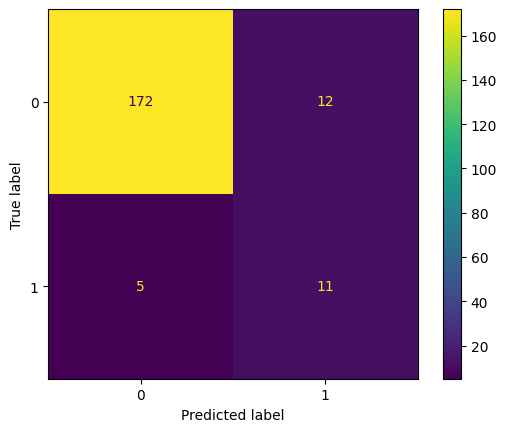

In [59]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.show()

Because the samples were mostly created in only one region, still a bunch of mismatches persist.

In [60]:
knc = KNeighborsClassifier()

knc.fit(X_balanced, y_balanced)
y_pred = knc.predict(X_test)
print('Score for TKRKNN data: ', f1_score(y_pred, y_test))

Score for TKRKNN data:  0.5454545454545454


In [61]:
scores.append(['KNC', 'TKRKNN', f1_score(y_pred, y_test)])

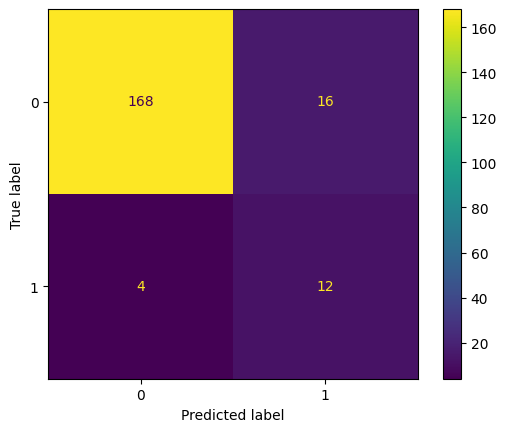

In [62]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.show()

There is no doubt that it is the best performance achieved for true positives by KNC.

## **SLS**

In [63]:
sls = SLS()

df_balanced = sls.balance(pd.concat([X_train, y_train], axis=1).copy().reset_index(drop=True), 'Legendary')

X_balanced = df_balanced.drop('Legendary', axis=1)
y_balanced = df_balanced['Legendary']

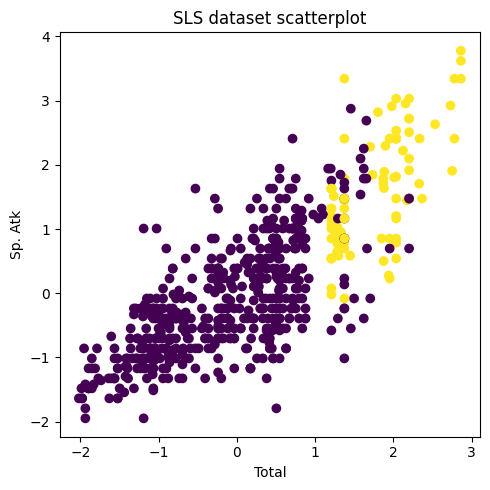

In [64]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))

colors = df_balanced['Legendary'].astype(int)

scatter = ax.scatter(df_balanced['Total'], df_balanced['Sp. Atk'], c=colors, cmap='viridis')

ax.set_title('SLS dataset scatterplot')
ax.set_xlabel('Total')
ax.set_ylabel('Sp. Atk')

plt.tight_layout()
plt.show()

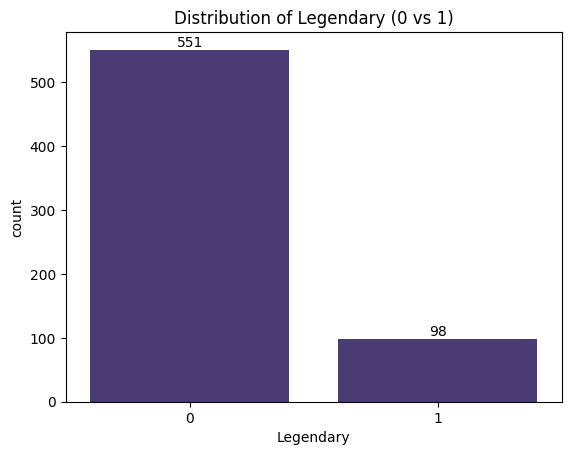

In [65]:
ax = sns.countplot(x=y_balanced)

ax.bar_label(ax.containers[0])

plt.title('Distribution of Legendary (0 vs 1)')
plt.show()

As we see, SNS hasn't found many safe spots, so the number of Legendary is not that big.

In [66]:
lr = LogisticRegression(random_state=42)

lr.fit(X_balanced, y_balanced)
y_pred = lr.predict(X_test)
print('Score for SLS data: ', f1_score(y_pred, y_test))

Score for SLS data:  0.625


In [67]:
scores.append(['LR', 'SLS', f1_score(y_pred, y_test)])

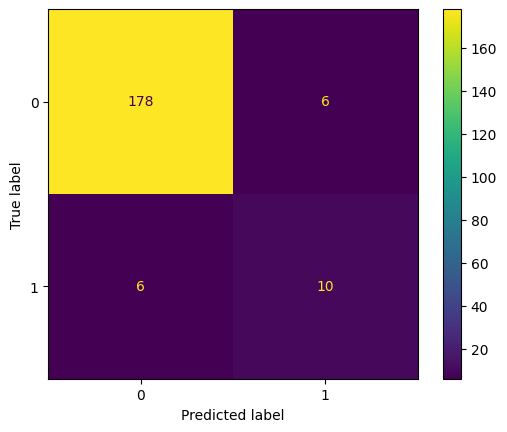

In [68]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.show()

Actually, it is not bad, but not the best.

In [69]:
knc = KNeighborsClassifier()

knc.fit(X_balanced, y_balanced)
y_pred = knc.predict(X_test)
print('Score for SLS data: ', f1_score(y_pred, y_test))

Score for SLS data:  0.6


In [70]:
scores.append(['KNC', 'SLS', f1_score(y_pred, y_test)])

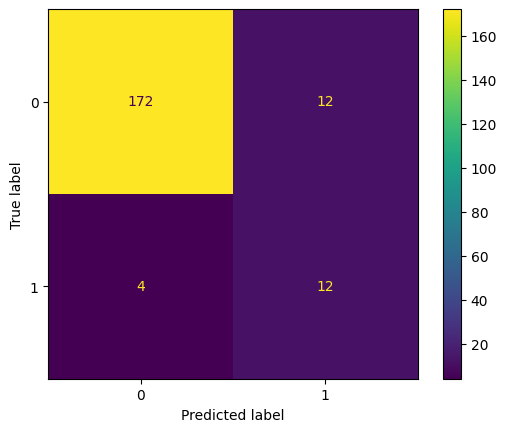

In [71]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.show()

Same for the KNC, but with TP increased and TN decreased.

## **MWMOTE**

In [72]:
X_train = X_train.apply(lambda col: col.astype(int) if col.dtype == 'bool' else col)

In [73]:
mwmote = MWMOTE()

df_balanced = mwmote.balance(pd.concat([X_train, y_train], axis=1).copy().reset_index(drop=True), 'Legendary')

X_balanced = df_balanced.drop('Legendary', axis=1)
y_balanced = df_balanced['Legendary']

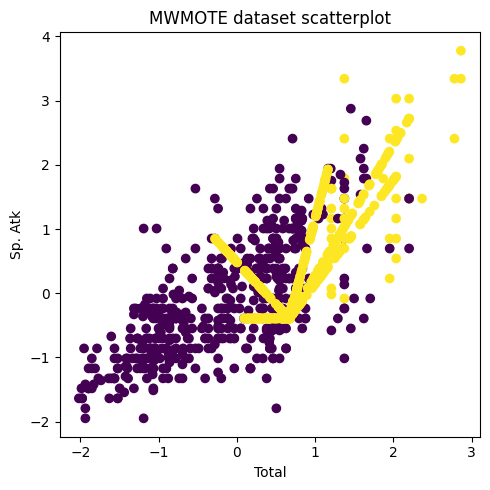

In [74]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))

colors = df_balanced['Legendary'].astype(int)

scatter = ax.scatter(df_balanced['Total'], df_balanced['Sp. Atk'], c=colors, cmap='viridis')

ax.set_title('MWMOTE dataset scatterplot')
ax.set_xlabel('Total')
ax.set_ylabel('Sp. Atk')

plt.tight_layout()
plt.show()

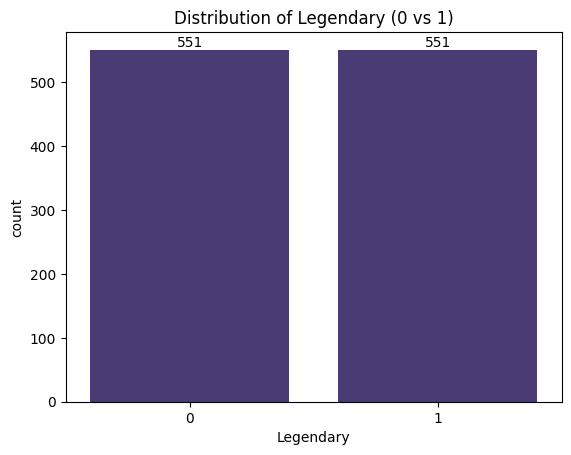

In [75]:
ax = sns.countplot(x=y_balanced)

ax.bar_label(ax.containers[0])

plt.title('Distribution of Legendary (0 vs 1)')
plt.show()

In [76]:
lr = LogisticRegression(random_state=42)

lr.fit(X_balanced, y_balanced)
y_pred = lr.predict(X_test)
print('Score for MWMOTE data: ', f1_score(y_pred, y_test))

Score for MWMOTE data:  0.5217391304347826


In [77]:
scores.append(['LR', 'MWMOTE', f1_score(y_pred, y_test)])

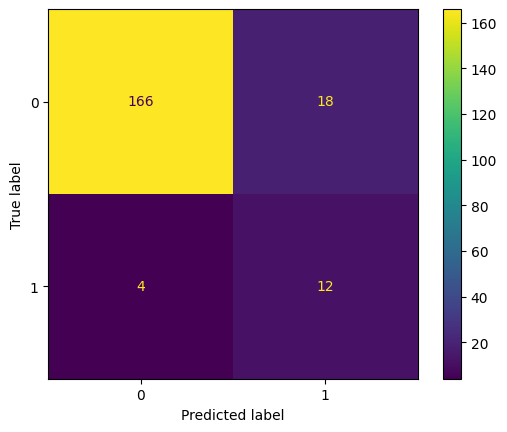

In [78]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.show()

Not as bad as it seems to be when looking at the plot. The TP rose in comparison with initial data.

In [79]:
knc = KNeighborsClassifier()

knc.fit(X_balanced, y_balanced)
y_pred = knc.predict(X_test)
print('Score for MWMOTE data: ', f1_score(y_pred, y_test))

Score for MWMOTE data:  0.3829787234042553


In [80]:
scores.append(['KNC', 'MWMOTE', f1_score(y_pred, y_test)])

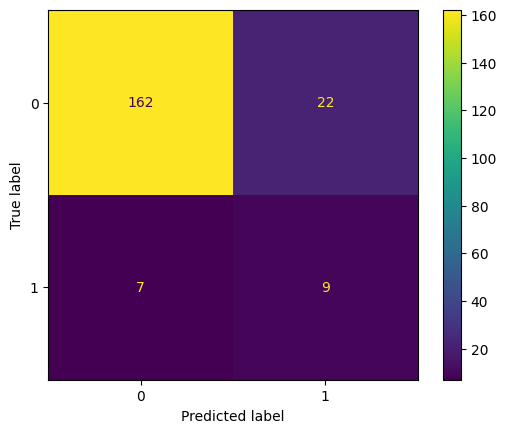

In [81]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.show()

There the difference shows up - because the samples created lie among the negatives, and are quite a lot, the model wrongly predicts them.

# **Conclusion**

Why do we need it? Because imbalanced data often produces harm, because models tend to predict the most popular categories. To avoid it, we need to synthetically produce new data.

How can it be useful? It helps build better predictive models.

Why there are so many? Because each of them is suitable for different cases. As we saw, for LogisticRegression TKRKNN and ICOTE were the best for true positives, while for KNeighborsClassifier TKRKNN gave the best true positives and SNS gave the best true negative/true positive ratio.

In [83]:
pd.DataFrame(scores, columns=['Estimator','Balancer','Score'])

,Estimator,Balancer,Score
0,LR,initial,0.428571
1,KNC,initial,0.562500
2,LR,SMOTE,0.590909
3,KNC,SMOTE,0.583333
4,LR,SMOTEENN,0.608696
5,KNC,SMOTEENN,0.571429
6,LR,ICOTE,0.606061
7,KNC,ICOTE,0.647059
8,LR,TKRKNN,0.564103
9,KNC,TKRKNN,0.545455


As we see, the best results are achieved by SMOTENN and SLS. Even though SLS is in the top, it is much worse in predicting TP than SMOTENN.

SLS made some new samples, but it still left the class imbalanced - what's why the results aren't brilliant.

SMOTENN, on the over side, deleted impostors and created new samples near other TP, hence achieving good results.